In [2]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


c:\Users\euyehara\experiment_control


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\cffi\cparser.py:436: UserWarning: #pragma in cdef() are entirely ignored. They should be removed for now, otherwise your code might behave differently in a future version of CFFI if #pragma support gets added. Note that '#pragma pack' needs to be replaced with the 'packed' keyword argument to cdef().
  warnings.warn(


Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply
VOA initialized to 4.99 volt


In [9]:
center_spot()

In [7]:
cam.close()

In [7]:
HVA_to_wavelength(57*u.V)


Magnitude,[[1341.9887359198997]]
Units,nanometer


In [2]:
ramp_VCSEL(0*u.V)
Vmon = Vmon_to_HVA(ch_HVA_Vmon.read())
# Vmon = ch_VOA.read()
print(Vmon)

0.09126546414977808 volt


In [8]:
wavvolt_HVCALIB

'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\wavvolt_HVCALIB_GSdev1b_delayvolt14_BOA700mA_2025-10-4.mat'

In [3]:
turn_VCSEL_off()

# Functions to test
    <!-- - find_raman() -->
    <!-- - HVA_to_wavelength() -->
    <!-- - parse_wav_delay() -->
    <!-- - set_VCSEL_wavelength() -->
    - find_maxPos()
    
    

(159,)
(1,)
(1,)
sweep time: 1.91 second
start time: Mon Jun  2 00:22:30 2025
stop time: Mon Jun  2 00:22:31 2025
(1,)
(1,)
(10, 158)
Peak at 1306.358 / centimeter
LIA voltage: 0.000 volt
Stokes wavelength: 1251.713 nanometer
MEMS voltage at 26.771 volt


C:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1864: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


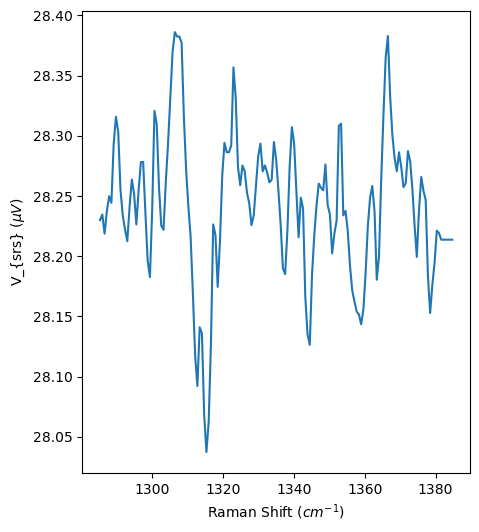

In [ ]:
raman_pk = 1335.24/u.cm
sweep_bw = 100 /u.cm
t_lia = 300*u.us
sens_lia = 300*u.uV
fixed_wav = 1075.8*u.nm
find_raman(raman_pk, sweep_bw, t_lia, sens_lia, fixed_wav, num_sweep=5)

In [1]:
wav_start = 1281*u.nm #1280*u.nm #1249*u.nm
wav_stop = 1343*u.nm #1342*u.nm #1276.8*u.nm
Δwav = 0.1*u.nm 
num_sweep=1
t_lia = 100*u.ms
fixed_wav = 1075.6*u.nm

_, write_data, record_data = configure_VCSEL_sweep(wav_start, wav_stop, Δwav, fixed_wav, num_sweep, t_lia, wavvolt_file=wavvolt_file, delayvolt_file=delayvolt_file, ch_sync=ch_sync, trig_params=None)


HV_sweep = HVA_to_daq(write_data["ch_VCSEL_MEMS_str"])
VOA_sweep = write_data["ch_VOA_str"]

plt.figure(figsize=(3,3))
plt.plot(range(HV_sweep.shape[0]), HV_sweep, '.')
plt.xlabel("index")
plt.ylabel("HVA sweep")

plt.figure(figsize=(3,3))
dv = np.diff(HV_sweep)
plt.plot(range(dv.shape[0]), dv,'.')
plt.xlabel("index")
plt.ylabel("HVA diff")

plt.figure(figsize=(3,3))
plt.plot(range(VOA_sweep.shape[0]), VOA_sweep, '.')
plt.xlabel("index")
plt.ylabel("VOA sweep")

NameError: name 'u' is not defined

# Collect Wavvolt

In [7]:
sample_dir = "dev1b_GS-SS"
name = "GSdev1b_BOA700mA_delayvolt14_0-72V"

init_voltage = 0*u.V  # [V]
end_voltage = 44*u.V # [V]
increment = 1*u.V  # Voltage increment
voltage_list = np.arange(init_voltage.m, end_voltage.m+increment.m, increment.m)* u.V

#Remove if wavvolt changes!
voltage_list = np.append(voltage_list.m, np.arange(57, 72+1, 1))*u.V
print(voltage_list)

osa_settings = {
    "rbw": 0.1*u.nm,
    "ref_level": -10*u.dimensionless,
    "wav_start": 1230*u.nm,
    "wav_stop": 1360*u.nm
}
num_avg=5

# ramp_VCSEL(1*u.V) #turn on
ds=generate_wavvolt(voltage_list, osa_settings, num_avg, sample_dir=sample_dir, name=name)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] volt
saving data to: 
C:\Users\euyehara\experiment_control\calibration_data\VCSEL_calibration\Sample_dev1b_GS-SS_2025-05-29-01-16-40\wavvoltdata_GSdev1b_BOA700mA_delayvolt14_0-72V_2025-10-04-21-57-02.h5
Voltage set: 0.0000 V...
Voltage measured: 0.1235 V


c:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1545: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  spectrum_array[ind, :] = np.reshape(spectra, (1, int(trace_len)))


Voltage set: 1.0000 V...
Voltage measured: 1.1039 V
Voltage set: 2.0000 V...
Voltage measured: 2.1229 V
Voltage set: 3.0000 V...
Voltage measured: 3.0710 V
Voltage set: 4.0000 V...
Voltage measured: 4.0514 V
Voltage set: 5.0000 V...
Voltage measured: 5.0704 V
Voltage set: 6.0000 V...
Voltage measured: 6.0443 V
Voltage set: 7.0000 V...
Voltage measured: 7.0698 V
Voltage set: 8.0000 V...
Voltage measured: 8.0889 V
Voltage set: 9.0000 V...
Voltage measured: 9.0499 V
Voltage set: 10.0000 V...
Voltage measured: 10.0431 V
Voltage set: 11.0000 V...
Voltage measured: 11.0557 V
Voltage set: 12.0000 V...
Voltage measured: 12.0683 V
Voltage set: 13.0000 V...
Voltage measured: 13.0873 V
Voltage set: 14.0000 V...
Voltage measured: 14.0290 V
Voltage set: 15.0000 V...
Voltage measured: 15.0158 V
Voltage set: 16.0000 V...
Voltage measured: 16.0026 V
Voltage set: 17.0000 V...
Voltage measured: 17.0087 V
Voltage set: 18.0000 V...
Voltage measured: 18.0020 V
Voltage set: 19.0000 V...
Voltage measured: 19

In [10]:
fname = "wavvoltdata_GSdev1b_BOA700mA_delayvolt14_0-72V_2025-10-04-21-57-02.h5"
sample_dir = calib_dir
dir_name ="Sample_dev1b_GS-SS_2025-05-29-01-16-40"

fpath = os.path.join(sample_dir, dir_name)
ds = load_data_from_file(fpath, fname)

loading file: wavvoltdata_GSdev1b_BOA700mA_delayvolt14_0-72V_2025-10-04-21-57-02.h5
importing meas_volt_list...
importing meas_wavmon_list...
importing pk_wl_list...
importing spectrum_array...
importing voltage_list...
importing wavelength...
importing attr num_avg...
importing attr rbw...
nanometer
importing attr rbw_units...
importing attr ref_level...
dimensionless
importing attr ref_level_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...


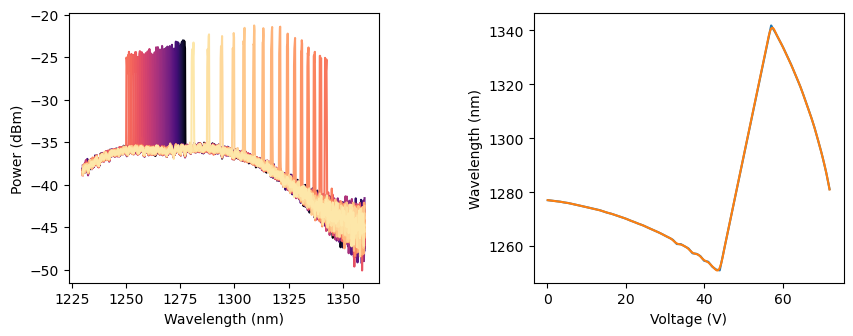

In [17]:
name="GSdev1b_delayvolt14_BOA700mA"
sample_dir=calib_dir
volt_stop=None#88.6*u.V
smooth_param=200

# save_wavvolt(ds, volt_stop=volt_stop, smooth_param=smooth_param, name=None,sample_dir=None)
save_wavvolt(ds, volt_stop=volt_stop, smooth_param=smooth_param, name=name,sample_dir=sample_dir)

# Raman Peak Search

In [82]:
ramp_VCSEL(38.3*u.V)

sweep time: 3.80 second
start time: Tue Jun  3 02:07:51 2025
stop time: Tue Jun  3 02:07:55 2025
(6, 157)
Peak at 1372.619 / centimeter
LIA voltage: -0.000 volt
Stokes wavelength: 1262.004 nanometer
MEMS voltage at 37.881 volt


ValueError: x and y must have same first dimension, but have shapes (158,) and (157,)

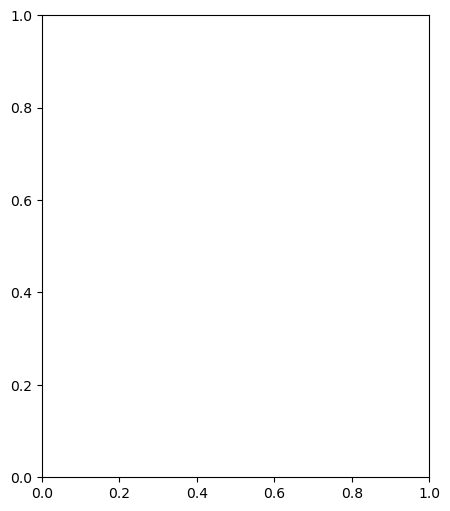

In [83]:
# Find Raman Peak
raman_pk = 1335/u.cm
sweep_bw = 100 /u.cm
t_lia = 1*u.ms
sens_lia = 300*u.uV
fixed_wav = 1075.6*u.nm
Δwav = 0.1*u.nm 
num_sweep = 3

find_raman(raman_pk, sweep_bw, t_lia, sens_lia, fixed_wav, Δwav, num_sweep)

# DAQ Continuous Sweep

In [2]:
sample_dir = 'GSdev1b_delayvolt14'
name = 'HVA_wavelength_calibration_monfilt1300.5nm_300us'
# name = 'diamondCarotene_01nm_1240-1276.8nm_100us1mV'

t_lia = 300*u.us
sens_lia = 1 * u.mV
wav_start = 1281*u.nm #1280*u.nm #1249*u.nm
wav_stop = 1343*u.nm #1342*u.nm #1276.8*u.nm
Δwav = 0.1*u.nm 
num_sweep = 20
fixed_wav = 1075.6*u.nm
ds = VCSEL_sweep_spectrum(wav_start, wav_stop, Δwav, num_sweep, t_lia, sens_lia, fixed_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_GSdev1b_delayvolt14_2025-10-04-22-17-51\Spectra_HVA_wavelength_calibration_monfilt1300.5nm_300us_2025-10-04-23-37-30.h5
Wavelength out of range: 1342.00 nanometer
Wavelength out of range: 1342.10 nanometer
Wavelength out of range: 1342.20 nanometer
Wavelength out of range: 1342.30 nanometer
Wavelength out of range: 1342.40 nanometer
Wavelength out of range: 1342.50 nanometer
Wavelength out of range: 1342.60 nanometer
Wavelength out of range: 1342.70 nanometer
Wavelength out of range: 1342.80 nanometer
Wavelength out of range: 1342.90 nanometer
Wavelength out of range: 1343.00 nanometer
V_MEMS_sweep: 12181
V_MEMS_pad_fwd: 12181
V_VOA_sweep: 12181
num_samp: 12181
sweep time: 21.93 second
start time: Sat Oct  4 23:37:32 2025
stop time: Sat Oct  4 23:37:54 2025
dumping item: num_sweep
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
microsecond
dumping item: sens_lia
non-a

c:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:2466: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]


Peak at 1678.167 / centimeter


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


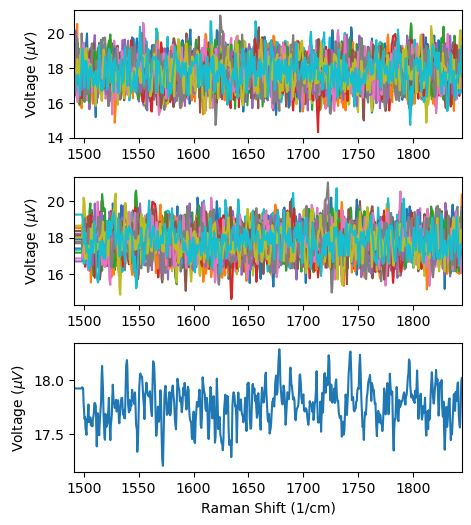

In [10]:
fpath = None #os.path.join(data_dir,"Sample_GSdev1b_delayvolt13_2025-06-02-23-15-28")
fname = name 
fig = plot_daq_sweepSpectra(ds, fname=fname, fpath=fpath, wavvolt_HVCALIB=wavvolt_file)

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\numpy\lib\function_base.py:628: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  a = asarray(a, dtype=dtype, order=order)
c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


Text(0, 0.5, 'Meas HVA (V)')

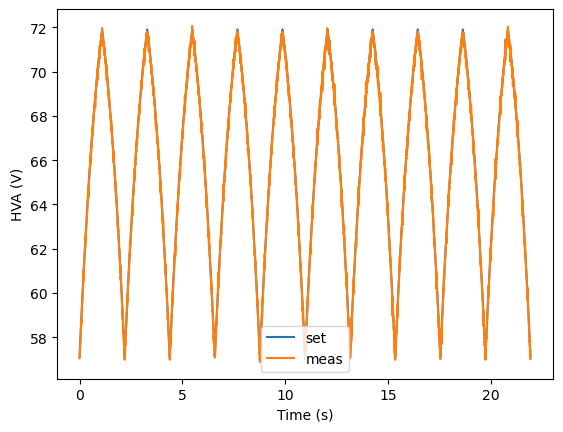

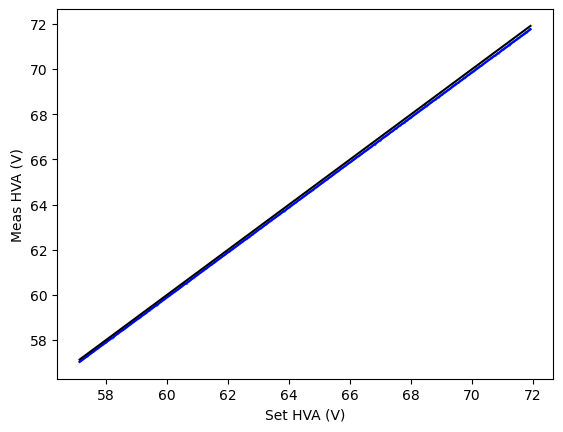

In [ ]:
t=ds['t'][1:]
HVA_Vset_wrap = VCSEL_sweep_volts(ds['HVA_Vset'], num_sweep)
HVA_Vset = ds['HVA_Vset']
VOA_Vset = ds['VOA_Vset']
HVA_Vraw = Vmon_to_HVA(ds['HVA_Vraw'][1:])
VCSEL_wavmon_raw = ds['VCSEL_wavmon_raw'][1:]

HVA_mean = np.mean(ds['HV_arr'].transpose(), axis=1)

def line(x,a,b):
    return a*x + b

popt,_ = curve_fit(line, HVA_Vset.to(u.V).m, HVA_mean)
HVA_linfit = line(HVA_Vset.m, popt[0], popt[1])


plt.figure()
plt.plot(t, HVA_Vset_wrap, label='set')
plt.plot(t, HVA_Vraw, label='meas')
plt.xlabel("Time (s)")
plt.ylabel("HVA (V)")
plt.legend()

# plt.figure()
# plt.plot(t, VCSEL_wavmon_raw)
# plt.xlabel("Time (s)")
# plt.ylabel("Wav mon (V)")

plt.figure()
plt.plot(ds['HVA_Vset'], np.mean(ds['HV_arr'].transpose(), axis=1))
plt.plot(HVA_Vset, HVA_linfit,'b')
plt.plot(ds['HVA_Vset'],ds['HVA_Vset'], 'k')
plt.xlabel("Set HVA (V)")
plt.ylabel('Meas HVA (V)')

In [ ]:
def calibrate_HVAset(calib_fname, calib_dir=calib_dir, verbose=False):
    """
    Calibrate HVA set voltage to correct for measured offset error
    """
    fpath = os.path.join(calib_dir, calib_fname)
    print(f'fpath: {fpath}')
    
    ds = load_hdf5(fpath=fpath)

    def line(x,a,b):
        return a*x + b

    def invert_line(y,a,b):
        return (y-b)/a

    HVA_Vset = ds['HVA_Vset'] 

    HVA_mean = np.mean(ds['HV_arr'].transpose(), axis=1)

    # Linear fit of measured HVA voltage
    popt,_ = curve_fit(line, HVA_Vset.to(u.V).m, HVA_mean)
    HVA_linfit = line(HVA_Vset.m, popt[0], popt[1])

    # For each voltage in HVA Vset, calculate the corrected set voltage to achieve the actual set value
    HVA_corrset = invert_line(HVA_Vset.m, popt[0], popt[1])

    if verbose:
        fig, ax = plt.subplots(1,1, figsize=(5,4), tight_layout=True)
        ax.plot(HVA_Vset, HVA_mean, 'b', label='mean')
        ax.plot(HVA_Vset, HVA_Vset, 'k', label='set')
        ax.plot(HVA_Vset, HVA_linfit, 'r', label='lin fit')
        ax.plot(HVA_Vset, HVA_corrset, 'g', label='corr set')
        
    return HVA_corrset

In [42]:
name = 'Spectra_HVA_wavelength_calibration_monfilt1300.5nm_300us_2025-10-04-23-37-30.h5'

HVA_corrset = calibrate_HVAset(name, calib_dir=calib_dir, verbose=True)

fpath: C:\Users\euyehara\experiment_control\calibration_data\VCSEL_calibration\Spectra_HVA_wavelength_calibration_monfilt1300.5nm_300us_2025-10-04-23-37-30.h5
loading file: Spectra_HVA_wavelength_calibration_monfilt1300.5nm_300us_2025-10-04-23-37-30.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
microsecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\numpy\lib\function_base.py:628: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  a = asarray(a, dtype=dtype, order=order)


DimensionalityError: Cannot convert from 'volt' to 'dimensionless'

0.04013433854986831 volt


Text(0, 0.5, 'dvoa')

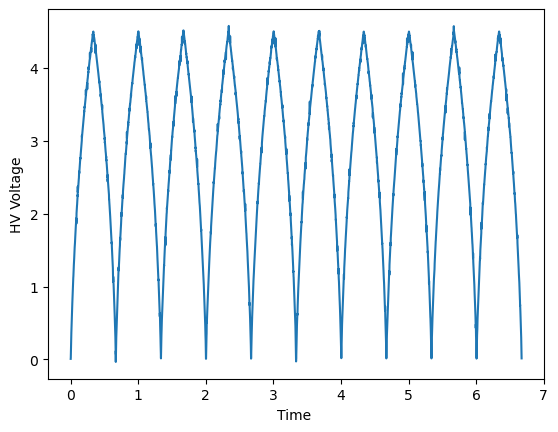

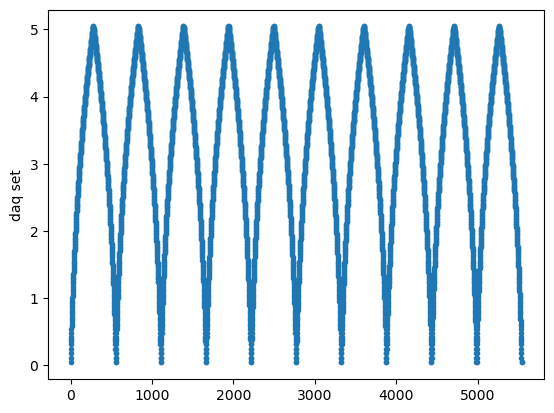

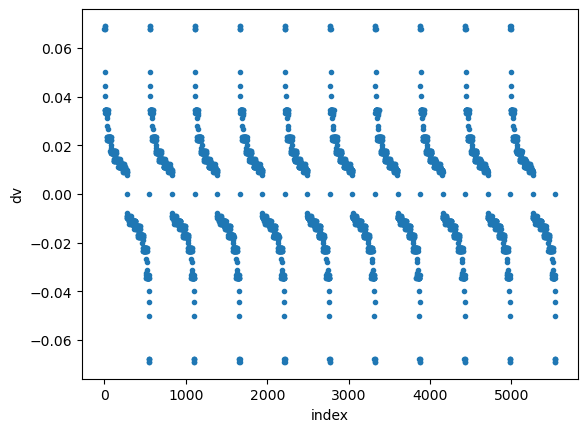

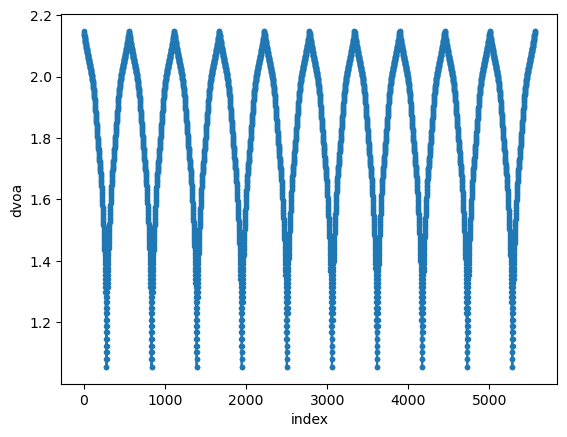

In [6]:
# %matplotlib qt

# fname = "Spectra_NoVCSEL_sweep_testHVNoise_noTVSdiode_300us_2025-06-02-00-57-50.h5"
# sample_dir = data_dir
# dir_name ="Sample_GSdev1b_2025-06-01-00-49-47"
# fpath = os.path.join(sample_dir, dir_name)
# ds = load_data_from_file(fpath, fname)

HVA_Vset = ds["HVA_Vset"][:-1]
wavelength_set = ds["wavelength_set"][:-1]
HV_arr = ds["HV_arr"][:,:-1]
raman_shift = ds["raman_shift"][:-1]
offset = 0*u.V
Vsrs_arr = (ds["Vsrs_arr"][:,:-1] / 10 + offset).to(u.V).m * ds["sens_lia"].to(u.V)
HVA_Vraw = ds['HVA_Vraw'].to(u.V).m,
Vsrs_Vraw = ds['Vsrs_Vraw'].to(u.V).m
t = ds['t']
V_VOA = ds['VOA_Vset']
daq_set = np.zeros(HVA_Vset.shape)
# V_MEMS_sweep = ds['ch_VCSEL_MEMS_str']
for i,V in enumerate(HVA_Vset): 
    daq_set[i] = HVA_to_daq(V).m
V_MEMS_sweep=configure_VCSEL_sweep(daq_set*u.V, 10)
V_VOA_sweep=configure_VCSEL_sweep(V_VOA, 10)

plt.figure()
plt.plot(t, HVA_Vraw[0]*10)
plt.xlabel("Time ")
plt.ylabel("HV Voltage")

plt.figure()
plt.plot(range(V_MEMS_sweep.shape[0]), V_MEMS_sweep, '.')
plt.ylabel("daq set")

dv = np.diff(V_MEMS_sweep)
plt.figure()
plt.plot(range(dv.shape[0]), dv,'.')
plt.xlabel("index")
plt.ylabel("dv")
# print(np.min(np.abs(dv)).to(u.mV))
print(V_MEMS_sweep[0])

dvoa = np.diff(V_VOA_sweep)
plt.figure()
plt.plot(range(V_VOA_sweep.shape[0]), V_VOA_sweep, '.-')
plt.xlabel("index")
plt.ylabel("dvoa")
# print(V_VOA)
# Vsrs_interp_arr = calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HV_arr, HVA_Vset, wavvolt_HVCALIB=wavvolt_HVCALIB)

In [213]:
sample_dir = "GSDev1a_inline"
filename = "Spectra_findDiamond_2025-03-31-20-25-07.h5"
ds = load_data_from_file(sample_dir, filename)
wavvolt_HVCALIB = os.path.join(calib_dir, "wavvolt_HVCALIB_GSDev1a_9.2mW_2025-3-31.mat") #For post-acquisition wavelength calibration

loading file: Spectra_findDiamond_2025-03-31-20-25-07.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing Vsrs_interp_arr...
importing raman_shift...
importing t...
importing wav_est_arr...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


# DAQ Step Sweep

In [11]:
osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

In [16]:
#Test DAQ VCSEL step sweep
sample_dir = 'Test_DAQ_VCSEL_sweep'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'testGS_sweep_MM_full'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 1*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm

calib_dir = 'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\'
wavvolt_file = calib_dir + 'wavvolt-trunc_Dev1a_25C_OEland1076_5.72mW_2025-3-17.mat'
delayvolt_file = calib_dir + 'delayvolt3.mat'


ds = VCSEL_step_spectrum(osa, wavvolt_file, delayvolt_file, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)
# ds = VCSEL_step_spectrum(osa, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_DAQ_VCSEL_sweep_2025-03-25-18-27-43\Spectra_testGS_sweep_MM_full_2025-03-26-19-07-01.h5
dumping item: num_avg
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wav_settle_time
non-array, non-list item with units:
second
dumping item: wavelength_set
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 60.80 second
start time: Wed Mar 26 19:07:11 2025
stop time: Wed Mar 26 19:08:12 2025
dumping item: spec
dumping item: daq_Vset
dumping item: HVA_Vset
dumping item: VOA_Vset
dumping item: V_mon
dumping item: raman_shift
dumping item: pump_wl_

# Single Wavelength Measurement

In [191]:
sample_dir = "PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point"
# name = "R_ycut-LN_DSP_Y(cZ)Y_30ms3uV_O110mW_S27mW_986"
name = "VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV"
# name = "OElandSweep_T_30ms3uV_120s_985_HWP_SHG-LP_50mW_noF-F"

t_lia = 3*u.ms
n_rep = 50
pump_wav = 1072.6*u.nm
stokes_wav = 1251.7*u.nm

ds_point = acquire_point(t_lia, n_rep, pump_wav, stokes_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point_2024-12-14-21-35-34\WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: pump_wav
non-array, non-list item with units:
nanometer
dumping item: stokes_wav
non-array, non-list item with units:
nanometer
acquisition time: 600.00 millisecond
start time: Sun Dec 15 16:39:49 2024
stop time: Sun Dec 15 16:49:49 2024
dumping item: srs
loading file: WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
importing srs...
importing attr fsamp...
hertz
importing attr fsamp_units...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr stokes_wav...
nanometer
importing attr stokes_wav_units...
importing attr t_lia...
millisecond


# Source Meter Step Sweep

osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

[pk_wls, _] = osa.get_peak_info()
print(pk_wls[0])
print(pk_wls[1])

In [5]:
span = 1300*u.nm - 1230*u.nm
center_wl = np.round(span/2) + 1250*u.nm
osa.set_wavelength_span(span)
osa.set_center_wavelength(center_wl)

sample_dir = 'Test_VCSEL_sweep'
name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.2*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm


ds_spec = acquire_spectrum(osa, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=wav_settle_time, sample_dir=sample_dir, name=name)


fig=plot_spectra(ds_spec, sg_win_len=10)


plt.figure()
ind_arr = np.arange(0, s_wl.shape[0],1)
s_wl = savgol_filter(ds_spec["stokes_wl_meas"].m, 15,2)*u.m
plt.plot(ind_arr,s_wl)

# Continuous Sweep Spectrum (OE Land sweep)

In [10]:
sample_dir2 = "Test_VCSEL_sweep_CW"
name = "findDiamondsig"

t_lia = 10*u.ms
sens_lia = 100*u.uV
t_sweep = 120*1*u.s
wav_start = 1037.9*u.nm
wav_stop = 1080*u.nm
fixed_wav = 1256.4*u.nm
ds_spec = continuous_spectrum(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)
# ds_spec = continuous_spectrum_tap(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04\SpectraSweep_findDiamondsig_2025-03-31-19-35-48.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: t_sweep
non-array, non-list item with units:
second
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 120.00 second
start time: Mon Mar 31 19:35:48 2025
stop time: Mon Mar 31 19:37:48 2025
dumping item: spec
dumping item: wav_mon
loading file: SpectraSweep_findDiamondsig_2025-03-31-19-35-48.h5
importing spec...
importing wav_mon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr fsamp...
hertz
importing a

# Knife Edge Scan

In [4]:
cam.close()
stage = initialize_stage()
stage.connect()

Connecting to BPC203:
	- connecting to controller 71829423 --> done
	- connecting channel 1 (x axis) --> done
	- connecting channel 2 (y axis) --> done
	- connecting channel 3 (z axis) --> done




In [3]:
wf_illum_off()

In [5]:
pos = stage.get_axis_position('y')

In [79]:
stage.set_axis_position('y', 7)

	- moving y axis piezo to 7.000000 um --> done


In [90]:
stage.set_axis_position('y', 15)

	- moving y axis piezo to 15.000000 um --> done


In [91]:
stage.set_axis_position('y', 0)

	- moving y axis piezo to 0.000000 um --> done


σ = 1.33μm


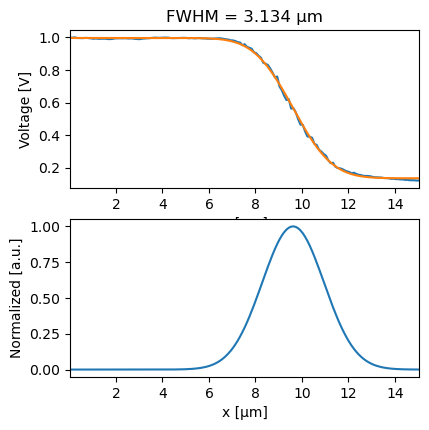

In [117]:
fig = plot_knife_scan(ds_spot)

In [116]:
scan_length = 15*u.um
axis = 'y'
step_size = 0.1*u.um
num_avg  = 3
# [ps_arr, pd_arr] = scan_single_axis(scan_length, axis, step_size, wait=0.5*u.s)
# ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='Nikon20xR_y_SiAu', name='Solstis985_pos38')
ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='BeamSpotMeas_Nikon20xT_y_GaAs', name='Dev1a-redo_Coverslip_pos47')

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_BeamSpotMeas_Nikon20xT_y_GaAs_2024-12-14-12-14-28\knifeScan_Dev1a-redo_Coverslip_pos47_2024-12-14-17-53-04.h5
15.033570360423598
scan time: 302.00 second
start time: Sat Dec 14 17:53:04 2024
stop time: Sat Dec 14 17:58:06 2024
	- moving y axis piezo to 0.033570 um --> done
	- moving y axis piezo to 0.133570 um --> done
	- moving y axis piezo to 0.233570 um --> done
	- moving y axis piezo to 0.333570 um --> done
	- moving y axis piezo to 0.433570 um --> done
	- moving y axis piezo to 0.533570 um --> done
	- moving y axis piezo to 0.633570 um --> done
	- moving y axis piezo to 0.733570 um --> done
	- moving y axis piezo to 0.833570 um --> done
	- moving y axis piezo to 0.933570 um --> done
	- moving y axis piezo to 1.033570 um --> done
	- moving y axis piezo to 1.133570 um --> done
	- moving y axis piezo to 1.233570 um --> done
	- moving y axis piezo to 1.333570 um --> done
	- moving y axis piezo to 1.433570 um --> d

In [80]:
move_spot(0.1*u.volt, 0*u.volt)

In [60]:
move_spot(-0.1*u.volt, -0.24*u.volt)

In [67]:
center_spot()

# Galvo Scan

In [60]:
HVA_to_wavelength(70.9*u.V)

Magnitude,[[1285.953692115144]]
Units,nanometer


In [62]:
ramp_VCSEL(70.9*u.V)

sweep time: 1.90 second
start time: Tue Jun  3 02:01:30 2025
stop time: Tue Jun  3 02:01:32 2025
(20, 78)
Peak at 1336.790 / centimeter
LIA voltage: -0.000 volt
Stokes wavelength: 1256.329 nanometer
MEMS voltage at 37.811 volt


ValueError: x and y must have same first dimension, but have shapes (79,) and (78,)

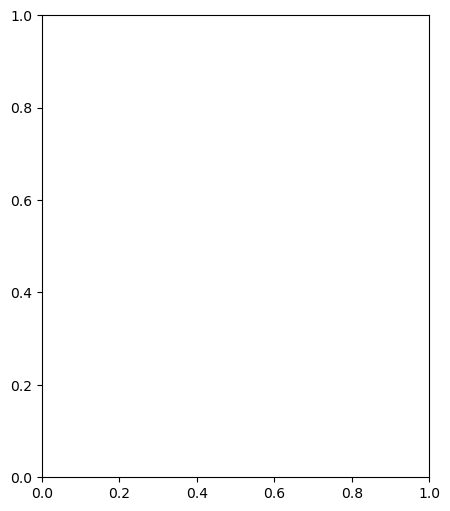

In [69]:
# Find Raman Peak
raman_pk = 1337/u.cm
sweep_bw = 50 /u.cm
t_lia = 300*u.us
sens_lia = 300*u.uV
fixed_wav = 1075.6*u.nm
Δwav = 0.1*u.nm 
num_sweep = 10

find_raman(raman_pk, sweep_bw, t_lia, sens_lia, fixed_wav, Δwav, num_sweep)

In [70]:
ramp_VCSEL(38.3*u.V)

In [79]:
cam.close()

scan time: 162.00 second


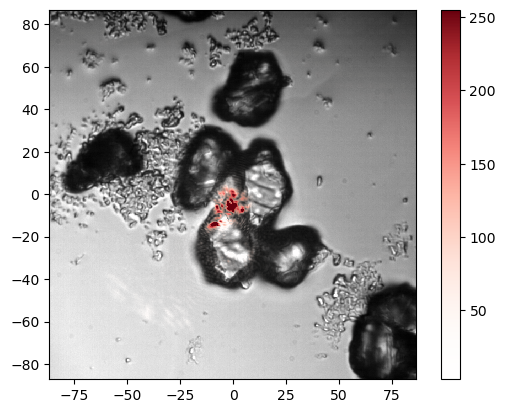

In [78]:
# Configure scan and preview scan area
# 3ms integration time
filename = "diamondCaroteneIPA_OEland1075.6-60mW_1mV300us_N300_1V_carotene3" 
sample_dir = "Sample_GSdev1b_delayvolt13_2025-06-02-23-15-28"

t_LIA = 300*u.us
nx, ny      =   300   ,   300 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(6*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=5*u.ms)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Sample_GSdev1b_delayvolt13_2025-06-02-23-15-28_2025-06-03-00-30-28\GalvoScan_diamondCaroteneIPA_OEland1075.6-60mW_1mV300us_N300_1V_carotene3_2025-06-03-01-37-25.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 162.00 second
start time: Tue Jun  3 01:37:27 2025
stop time: Tue Jun  3 01:40:09 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
no

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


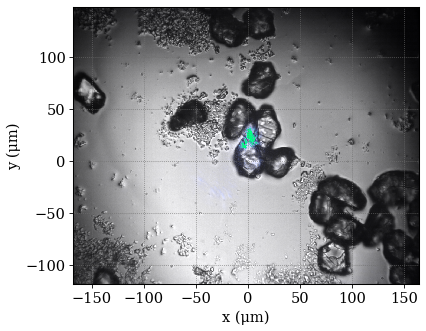

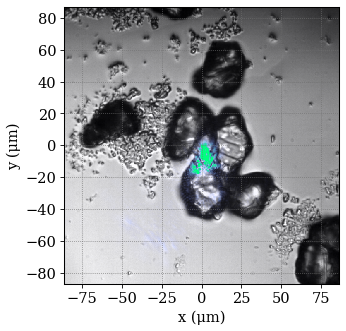

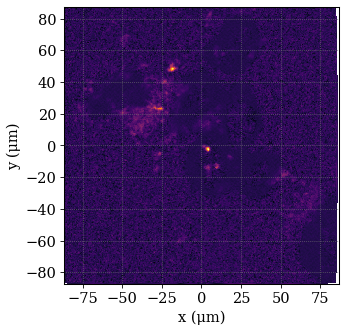

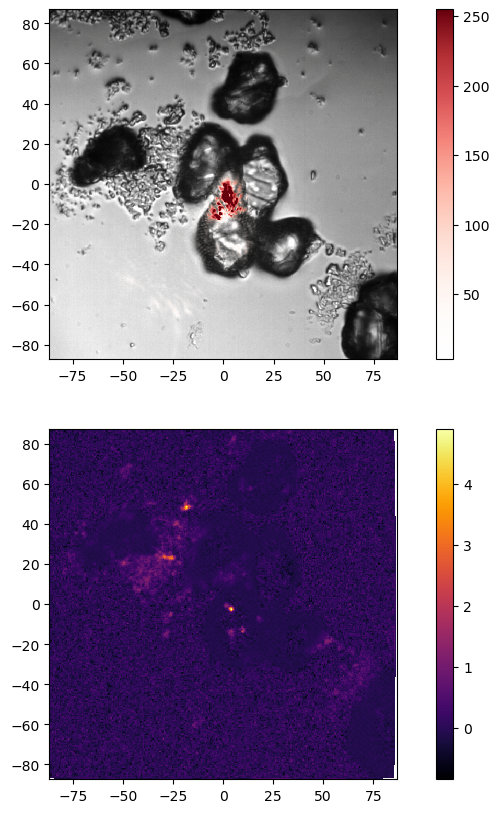

In [42]:
ds0 = collect_wfscan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,name=filename,sample_dir=sample_dir,wf_exposure_time=5*u.ms)
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno)

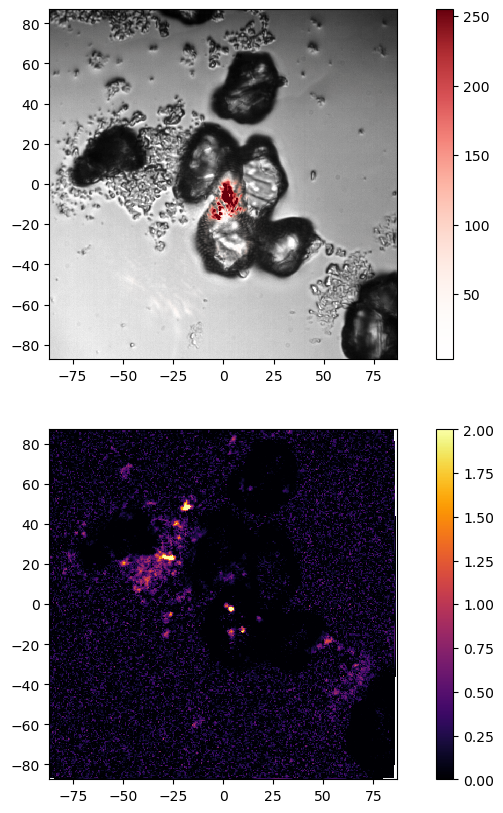

In [50]:
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=2)

TypeError: pcolormesh() takes 1 or 3 positional arguments but 6 were given

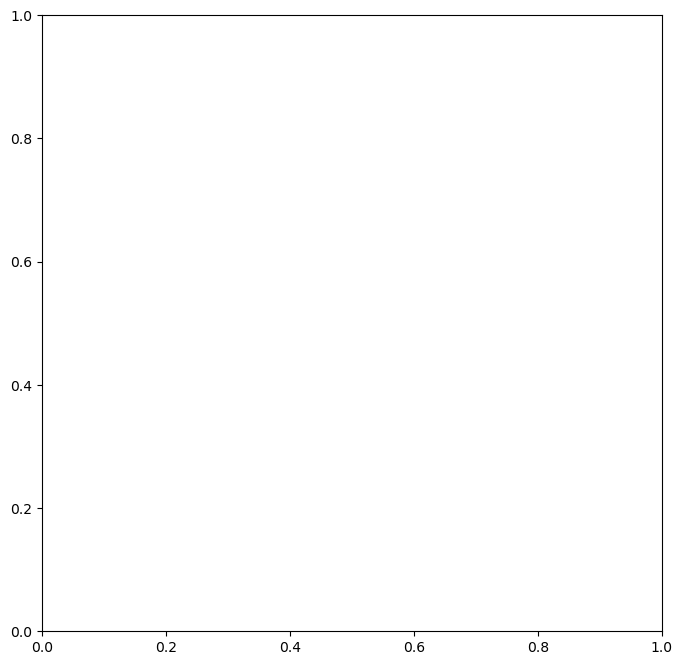

In [49]:
Vmx, Vmy = find_maxPos(ds0)

In [ ]:
def find_maxPos(ds, numMax=10, srs_cmap=cm.inferno, vmin=0, vmax=5):
    """
    Finds galvo voltages corresponding to numMax max SRS signals
    Returns (1,numMax) 1d arrays VMx, VMy
    """
    Vsrs_g = ds["Vsrs_g"]
    Vx = ds["Vx"]
    Vy = ds["Vy"]
    M = []
 
    Vsrs_1d = np.reshape(np.nan_to_num(Vsrs_g), (1, Vsrs_g.shape[0]*Vsrs_g.shape[1]))[0]
    sort_i = np.flip(np.argsort(Vsrs_1d))

    for i in range(numMax): #Vsrs_g ordered as (Vy, Vx)
        M.append(tuple(reversed(np.unravel_index(sort_i[i], Vsrs_g.shape))))
    VMx = np.array([Vx[M[i][0]].m for i in range(numMax)])*u.V
    VMy = np.array([Vy[M[i][1]].m for i in range(numMax)])*u.V

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    p0 = ax.pcolormesh(Vx.m, Vy.m, Vsrs_g.m, srs_cmap, vmin, vmax)
    for i in range(numMax):
        ax.scatter(Vx[M[i][0]], Vy[M[i][1]], facecolors='none', edgecolors='w', s=150)
        # print("VMx:", VMx[i])
        # print("VMy:", VMy[i])
    ax.set_aspect("equal")
    return VMx, VMy
    

In [6]:
def plot_scan_data(ds,wf_cmap=cm.gray,laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=None, vmax=None):
    """
    Plot 2x1 subplots with [0] laser spot superimposed on cropped widefield image, and [1] SRS image
    :param ds: from collect_scan()
    :return: fig with (2) subplots
    """
    laser_cmap = transparent_cmap(laser_cmap)
    fig, ax = plt.subplots(2,1, figsize = (10,10))
    
    # Find wf image indices corresponding to scan area, add manual offset to match scan area
    i_xmax, i_xmin, i_ymax, i_ymin = wf_img_inds(ds)
    x_off = 0#10
    y_off = 0#40
    i_xmax += x_off
    i_xmin += x_off
    i_ymin += y_off
    i_ymax += y_off
 
    # [0] Laser spot + cropped widefield image
    im0 = ax[0].pcolormesh(ds["y_img"][i_ymin:i_ymax], ds["x_img"][i_xmin:i_xmax],
                              ds["wf_img"][i_xmax:i_xmin:-1, i_ymin:i_ymax], cmap=wf_cmap)
    im1 = ax[0].pcolormesh(ds["y_img"][i_ymin:i_ymax], ds["x_img"][i_xmin:i_xmax],
                              ds["laser_spot_img"][i_xmax:i_xmin:-1, i_ymin:i_ymax], cmap=laser_cmap)
    cb0 = plt.colorbar(im1, ax=ax[0])
    ax[0].set_aspect("equal")

    # [1] SRS (galvo) image
    p0 = ax[1].pcolormesh(ds["y"].m, ds["x"].m, np.flipud(np.transpose(ds["Vsrs_g"].m)), cmap=srs_cmap, vmin=vmin, vmax=vmax)
    cb1 = plt.colorbar(p0, ax=ax[1])
    ax[1].set_aspect("equal")

    plt.show()
    return fig

# Manual widefield image+ scan

scan time: 900.00 second


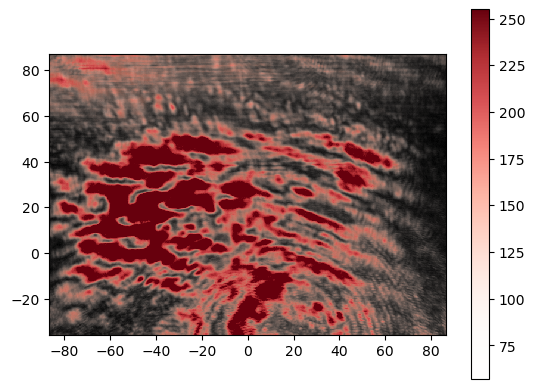

In [14]:
sample_dir= "GSDev1a" 
filename = "diamondPowder_GSDev1a-1256.8_OEland1075.6-71mW_300uV3ms_manual"

t_LIA = 3*u.ms
nx, ny      =   150   ,   150 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(4*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=81*u.ms)

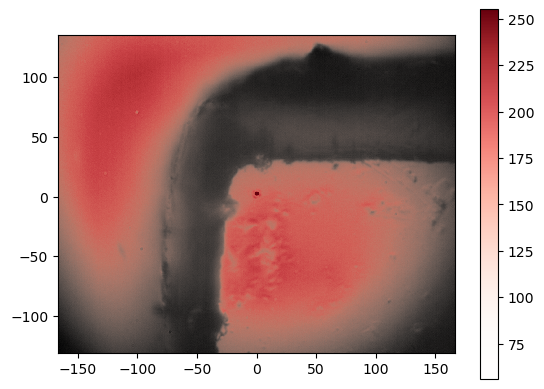

In [4]:
# Take laser spot and widefield image
wf_img, laser_spot_img = wf_and_laser_spot_images(exposure_time=81*u.ms)
fig = plot_laser_widefield_img(wf_img, laser_spot_img)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_diamond_SRL_GSDev1a_OEland1075.6-70mW_Nikon20x_2025-03-21-20-29-02\GalvoScan_Dev1a-1255.81_300uV3ms_1V150N_maxUp_2025-03-21-22-26-34.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 900.00 second
start time: Fri Mar 21 22:26:34 2025
stop time: Fri Mar 21 22:41:34 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-list item with 

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


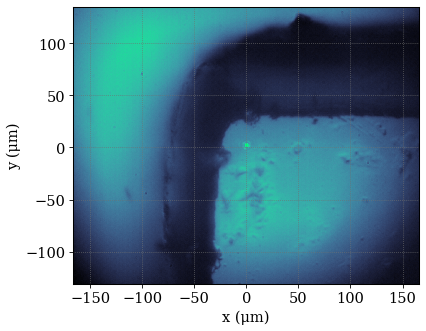

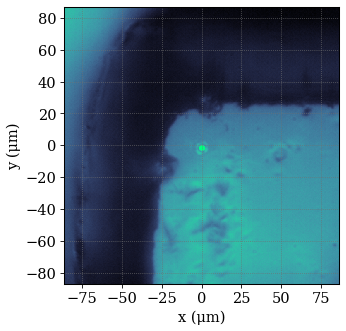

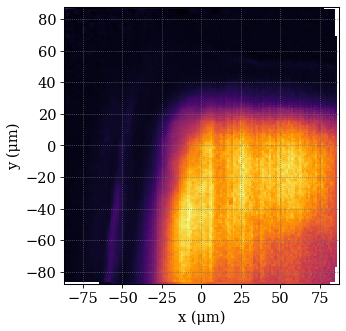

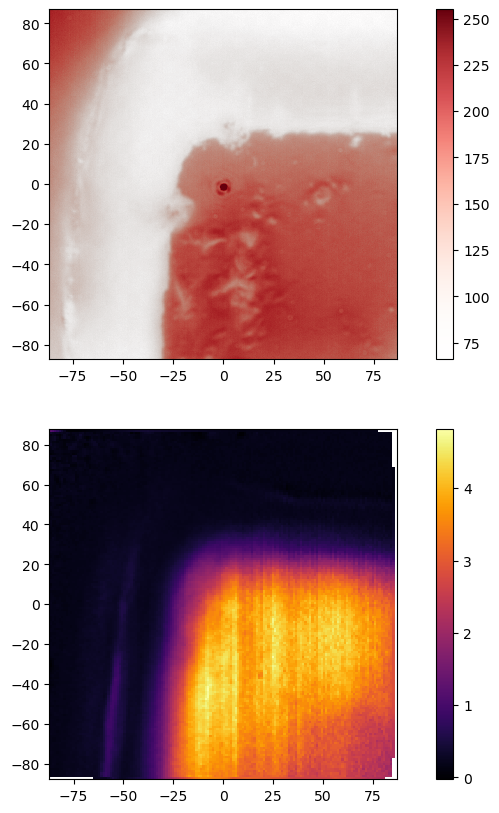

In [15]:
ds0 = collect_scan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,wf_img,laser_spot_img,name=filename,sample_dir=sample_dir)
fig = plot_scan_data(ds0, wf_cmap=cm.binary, laser_cmap=cm.Reds, srs_cmap=cm.inferno)